# ACHTUNG

Click `File` and `Save a copy in Drive` to run your own copy of this notebook on Google.

or

Click `File` and `Download -> Download .ipynb` to run a local copy.

# Intro to NN with Keras

- Design our fist neural net to solve a regression problem
- Introduce tensorflow's Keras library
- Evaluating trained model
- Visualizing the loss
- Improvements:
  - Hidden layers
  - Pre-processing: Scaling
  - Dropout


### Review of SciKit API

According to VanderPlas (2016):
1. Choose a class of model by **importing the appropriate estimator** class from Scikit-Learn.
2. Choose model **hyperparameters** by instantiating this class with desired values.
3. Arrange data into a **features matrix and target vector** following the discussion above.
4. **Fit the model** to your data by calling the ``fit()`` method of the model instance.
5. **Apply the model** to new data:
   - For supervised learning, often we predict labels for unknown data using the ``predict()`` method.
   - For unsupervised learning, we often transform or infer properties of the data using the ``transform()`` or ``predict()`` method. (p. 347)
   
   
``` python
from sklearn.svm import SVC #1
model = SVC(kernel='linear') #2

Xtrain, Xtest, ytrain, ytest = train_test_split(data.features, data.labels) #3a/b

model.fit(Xtrain, ytrain) #4

y_model = model.predict(Xtest) #5
```

VanderPlas, J. (2016). Python data science handbook: Essential tools for working with data. Sebastopol, CA: O'Reilly Media.

## Linear Regression

Hypothesis

$h(x) = \sum_{i=1}^n wx_i $

Prediction art

$x_0 \rightarrow w_0 \searrow $

$x_1 \rightarrow w_1 \rightarrow $   $\sum \longrightarrow $ h(x)

$\ldots$

$x_m \rightarrow w_m \nearrow $

[Cost function](https://scikit-learn.org/stable/modules/linear_model.html#ordinary-least-squares)

## Classification via Logistic Regression

Hypothesis

Let $y = \{-1, 1 \}$ or $y = \{0, 1 \}$


$ h(x) = \text{sigmoid}(\sum_{i=1}^n wx_i ) $

Prediction art

$x_0 \rightarrow w_0 \searrow $

$x_1 \rightarrow w_1 \rightarrow $   $\sum  \rightarrow$ Sigmoid() $\longrightarrow $ h(x)

$\ldots$

$x_m \rightarrow w_m \nearrow $



# Regression: Housing Cost Prediciton

- Linear Regression approach via Scikit
- NN via tf.Keras

In [91]:
%matplotlib inline
from sklearn import datasets
import numpy as np
import matplotlib.pyplot as plt

In [92]:
from sklearn.datasets import fetch_california_housing

# Load as pandas DataFrame
X, y = fetch_california_housing(return_X_y=True, as_frame=True)
X.head()#, y.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:

    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None



This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per census
block group. A block group is the smallest geographical unit for which the U.S.
Census Bureau publishes sample data (a block group typically has a population
of 600 to 3,000 people).

A household is a group of people residing within a home. Since the average
number of rooms and bedrooms in this dataset are provided per household, these
columns may take surprisingly large values for block groups with few households
and many empty houses, such as vacation resorts.

It can be downloaded/loaded using the
:func:`sklearn.datasets.fetch_california_housing` function.

.. rubric:: References

- Pace, R. Kelley and Ronald Barry, Sparse Spatial Autoregressions,
  Statistics and Probability Letters, 33 (1997) 291-297


In [93]:
housing = fetch_california_housing()
print(housing.feature_names)

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [94]:
print(X.shape, y.shape)
print(y[:10])

(20640, 8) (20640,)
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
5    2.697
6    2.992
7    2.414
8    2.267
9    2.611
Name: MedHouseVal, dtype: float64


In [95]:
#split into Train / Test data:
from sklearn.model_selection import train_test_split

Xtrain, Xtemp, ytrain, ytemp = train_test_split(X, y, test_size=0.30, random_state=42)

Xval, Xtest, yval, ytest = train_test_split(Xtemp, ytemp, test_size=0.50, random_state=42)


print(Xtrain.shape, ytrain.shape)
print(Xtest.shape, Xval.shape)

(14448, 8) (14448,)
(3096, 8) (3096, 8)


In [96]:
from sklearn.linear_model import LinearRegression

model = LinearRegression(fit_intercept=False)
model.fit(Xtrain, ytrain)

#Note: if error: you may need np.asarray(...,dtype=np.float64)


,fit_intercept,False
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


MAE:  0.5915003935127343


Text(0.5, 1.0, 'Boston Housing True vs Predicted prices')

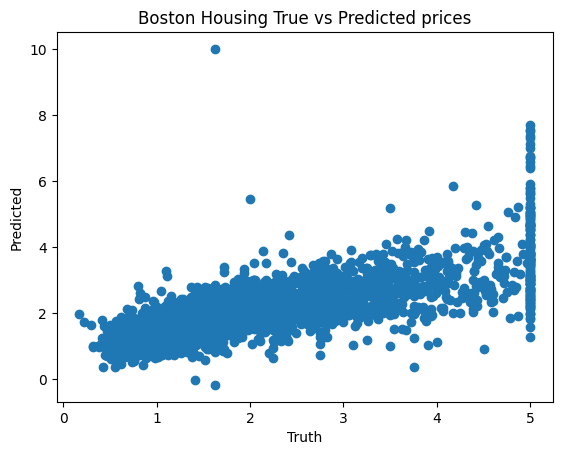

In [97]:
#Evaluate on test data
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

y_model = model.predict(Xtest)
#Calculate error and plot
mae = mean_squared_error(ytest, y_model)
print("MAE: ", mae)

#compare labels
plt.scatter(ytest, y_model)
plt.xlabel("Truth")
plt.ylabel("Predicted")
plt.title("Boston Housing True vs Predicted prices")

## Regression via NN

Will use DENSE layers: https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense


# From Logistic Regression to Neural Networks

Recall: **logistic regression** is a single linear layer producing $$z = w^\top x + b$$ followed by a **sigmoid** $$\sigma(z)$$, trained with **binary cross-entropy**.

A **neural network** generalizes this idea by stacking layers and nonlinearities:
- Hidden layers (e.g., ReLU) learn **nonlinear** feature transforms.
- Output layer & loss match the task
  -  sigmoid + BCE for binary classification,
  - linear + MSE for regression



Below, we'll build a small **regression** network with modern Keras. We'll also keep pointers where you'd swap the last layer/loss to mirror logistic regression.


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import models

tf.random.set_seed(42)

#Define your NN arch
def myNN(train_data):

#Initiate model:
  model = models.Sequential()

#First layer is special: It needs to match the shape of data:
    # units = 64: # of neurons; determines output shape of the layer.
    # input_shape: how many W needed per neuron?
    # Thus: input arrays of shape (*, 13). Output arrays of shape: (*, 64)
  model.add(layers.Dense(64, activation="leaky_relu", input_shape=(X.shape[1],), name="I"))

#Hidden layers will auto-size their input based the previous layer:
    #Can add more layers here to make it deeper...
  model.add(layers.Dense(32, activation="elu", name="H-I"))
  model.add(layers.Dense(24, activation="elu", name="H-II"))
  model.add(layers.Dense(16, activation="elu", name="H-III"))
  model.add(layers.Dense(8, activation="leaky_relu", name="H-IV"))
  model.add(layers.Dense(4, activation="swish", name="H-V"))
  model.add(layers.Dense(2, activation="swish", name="H-VI"))

#Output: Need a single number as our prediction:
    #Note that output layer has no activation
    # b/c this is a regression problem, not classification.
#How should the weights be calculated?
  model.add(layers.Dense(1, activation="sigmoid", name="O"))

#Cost design: loss function?
  model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
  return model


In [99]:
# %load keras-ex1.py


In [100]:
#build the model
model = myNN(Xtrain)

/home/evelyn/vs-code-workspace/embedded_ai/env/lib/python3.13/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [101]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ I (Dense)                       │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ H-I (Dense)                     │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ H-II (Dense)                    │ (None, 24)             │           792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ H-III (Dense)                   │ (None, 16)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ H-IV (Dense)                    │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ D-I (Dropout)                   │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ H-V (Dense)                     │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ D-II (Dropout)                  │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ H-VI (Dense)                    │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ O (Dense)                       │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,033 (15.75 KB)

 Trainable params: 4,033 (15.75 KB)

 Non-trainable params: 0 (0.00 B)

### Ex:

Why does `in` layer have 896 parameters?

In [102]:
#Algebra goes here?


## Train/Test your model


In [103]:
#Train: a la scikit:
#Scikit: model.fit(Xtrain, ytrain)
ne = 10
model.fit(Xtrain, ytrain, epochs=ne, batch_size=128, verbose=1)

Epoch 1/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 928us/step - loss: 2.6725 - mae: 1.2120 
Epoch 2/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.6140 - mae: 1.1946  
Epoch 3/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 962us/step - loss: 2.5789 - mae: 1.1824
Epoch 4/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.5547 - mae: 1.1750
Epoch 5/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 908us/step - loss: 2.5308 - mae: 1.1673
Epoch 6/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.5167 - mae: 1.1628
Epoch 7/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 841us/step - loss: 2.5074 - mae: 1.1597
Epoch 8/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 919us/step - loss: 2.4970 - mae: 1.1566
Epoch 9/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 874us/step - loss: 2.4916 - mae: 1.1549
Epoch 10/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.4877 - mae: 1.1536  


In [104]:
#Evalute our model:
#SciKit:
# y_model = model.predict(Xtest)
#Calculate error and plot
# mae = mean_squared_error(ytest, y_model)

nnmse, nnmae = model.evaluate(Xtest, ytest, verbose = 1)
print('NN Test MAE: ', nnmae)

97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 738us/step - loss: 2.4586 - mae: 1.1494
NN Test MAE:  1.149350881576538


### Keras model training API:

model.___()

- compile(): Configure model to be trained. Cost/loss function selection
- fit(): train for given # of iterations/epochs
- evaluate(): calculate loss given metrics
- predict(): what is my trained model's hypothesis?

More info at https://keras.io/api/models/model_training_apis/

### Bit more advanced training


In [105]:

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True
)

history = model.fit(
    Xtrain, ytrain,
    validation_data=(Xval, yval),
    epochs=200,
    batch_size=64,
    callbacks=[early_stop],
    verbose=0
)

len(history.history["loss"]), min(history.history["val_loss"])


(11, 2.443336248397827)

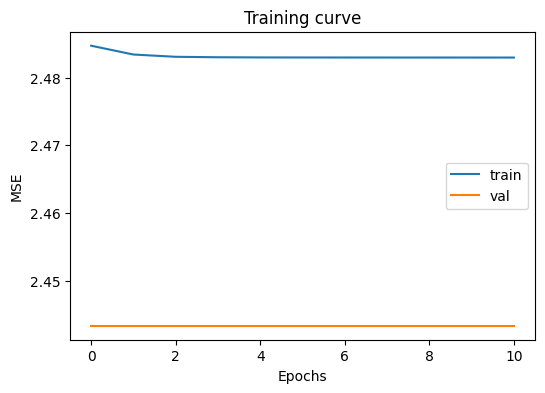

In [106]:

plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.legend()
plt.title("Training curve")
plt.show()


In [107]:
from sklearn.metrics import mean_absolute_error, r2_score

pred = model.predict(Xtest, verbose=0).ravel()
mae = mean_absolute_error(ytest, pred)
r2  = r2_score(ytest, pred)
print(f"Test MAE: {mae:.3f}")
print(f"Test R^2: {r2:.3f}")


Test MAE: 1.149
Test R^2: -0.859


## Ex

Giving the features for a new house, what do you think it costs?

In [108]:
housing.data[13]

array([   2.6736    ,   52.        ,    4.        ,    1.09770115,
        345.        ,    1.98275862,   37.84      , -122.26      ])

In [109]:
Xnew = np.array([2.7, 50, 3, 1.1, 333, 1.42, 33, -100])
Xnew = Xnew[np.newaxis, :]
## Predict ynew from Xnew:
Xnew.shape
model.predict(Xnew)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


array([[1.]], dtype=float32)

## How can we improve?

- tune network: add layers, train longer (i.e. epochs)
- cross-validation
- feature engineering

## Ex:
Tune the network above to drop the MAE.

Hint: Note that loss keeps dropping. Train the NN for longer.

In [ ]:
#Code goes here


### Preprocessing

What if we scale X?

In [111]:
from sklearn import preprocessing

print('Pre-scale: ', Xtrain[:2])
scaler = preprocessing.StandardScaler().fit(Xtrain)
Xtrains = scaler.transform(Xtrain)
#Apply the learned scaler to Test data:
Xtests = scaler.transform(Xtest)
print('Post-scale', Xtrains[:2])

Pre-scale:         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
7061   4.1312      35.0  5.882353   0.975490      1218.0  2.985294     33.93   
14689  2.8631      20.0  4.401210   1.076613       999.0  2.014113     32.79   

       Longitude  
7061     -118.02  
14689    -117.09  
Post-scale [[ 0.13350629  0.50935748  0.18106017 -0.27384968 -0.18411678 -0.01082519
  -0.80568191  0.78093406]
 [-0.53221805 -0.67987313 -0.42262953 -0.04786832 -0.37619075 -0.08931585
  -1.33947268  1.24526986]]


In [112]:
# for fun: we know how to do this ourselves:
xs = (Xtrain - Xtrain.mean(axis=0)) / (Xtrain.std(axis=0))
print('Post-scale', xs[:2])

Post-scale          MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
7061   0.133502   0.50934  0.181054  -0.273840   -0.184110 -0.010825   
14689 -0.532200  -0.67985 -0.422615  -0.047867   -0.376178 -0.089313   

       Latitude  Longitude  
7061  -0.805654   0.780907  
14689 -1.339426   1.245227  


## Ex:
How well does the scaled data do in 10 epochs, with 1 hidden layer?

In [113]:
#Solution goes here.


## Overview

- We created a MLP to predict housing prices

- Exposed to Keras/tf API

- Employed Dense hidden layers

- Discussed how to improve NN results

## NN Steps
- Data prep: Split train/test, pre-process, etc.
- Create model:
    - `model.Sequential()`
    - `model.add(layers….)`
    - Compile: loss function?
- Build model/review model summary: `model = myNN(Xtrains)`
- Train the model: `model.fit()`
- Evaluate on test data / cross-validate
- Repeat all of the steps above until satisfied/ran out of time
- Ready to predict on new data!

## To Do

- What is a Dense layer?

## Bonus Materials


## Plotting the loss

We can save the train/test history and plot it!


In [114]:
ne = 20
#Combine Train and Test to 1-step:
history = model.fit(Xtrain, ytrain, epochs=ne, verbose=1, validation_data = (Xtest, ytest)) #, batch_size=1
#Evalute our model:
# nnmse, nnmae = model.evaluate(Xtest, ytest, verbose = 1)

# History object is a dictionary with keys.
hd = history.history
print(hd)

Epoch 1/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 946us/step - loss: 2.4833 - mae: 1.1524 - val_loss: 2.4586 - val_mae: 1.1494
Epoch 2/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 937us/step - loss: 2.4830 - mae: 1.1523 - val_loss: 2.4586 - val_mae: 1.1494
Epoch 3/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 950us/step - loss: 2.4830 - mae: 1.1523 - val_loss: 2.4586 - val_mae: 1.1494
Epoch 4/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 929us/step - loss: 2.4830 - mae: 1.1523 - val_loss: 2.4586 - val_mae: 1.1494
Epoch 5/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 932us/step - loss: 2.4830 - mae: 1.1523 - val_loss: 2.4586 - val_mae: 1.1494
Epoch 6/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 2.4830 - mae: 1.1523 - val_loss: 2.4586 - val_mae: 1.1494
Epoch 7/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 936us/step - loss: 2.4830 - mae: 1.1523 - val_loss: 2.4586 - val_mae: 1.1494
Epoch 8/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 922us/step - loss: 2.4830 - mae: 1.1523 - val_loss: 2.4586 - val_mae: 1.1494
Epoch 9/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s

In [115]:
loss_tr = hd['loss']
loss_va = hd['val_loss']
epochs = range(0, ne)

import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

plt.plot(epochs, loss_tr, '-.o', label='Training loss')
plt.plot(epochs, loss_va, 'r', label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

ModuleNotFoundError: No module named 'seaborn'

## Dropout

- May help against overfitting
- by improving generalization

``The Dropout layer randomly sets input units to 0 with a frequency of `rate` at each step during training time,.."
https://keras.io/api/layers/regularization_layers/dropout/

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import models

#Old Syntax:
# from keras import layers

#Define your NN arch
def myNN(train_data):
#Initiate model:
    model = models.Sequential()
#First layer is special: It needs to match the shape of data:
    model.add(layers.Dense(64, activation='relu', input_shape=(train_data.shape[1],), name='in'))
    model.add(layers.Dropout(0.15))
    # units = 64: # of neurons; determines output shape of the layer.
    # input_shape: how many W needed per neuron?
    # Thus: input arrays of shape (*, 13). Output arrays of shape: (*, 64)
#Hidden layers will auto-size their input based the previous layer:
    model.add(layers.Dense(64, activation='relu', name='hidden1'))
    #Can add more layers here to make it deeper...
    model.add(layers.Dropout(0.15))

#Output: Need a single number as our prediction:
    model.add(layers.Dense(1, name='pred'))

    #Note that output layer has no activation
    # b/c this is a regression problem, not classification.
#How should the weights be calculated?
    model.compile(optimizer='rmsprop', loss='mse', metrics = ['mae'])
    return model


In [ ]:
#build the model
model = myNN(Xtrain)

In [ ]:
model.summary()

## Train/Test your model


In [ ]:
#Train: a la scikit:
#Scikit: model.fit(Xtrain, ytrain)
ne = 10
model.fit(Xtrain, ytrain, epochs=ne, verbose=1) #, batch_size=1

#Evalute our model:
nnmse, nnmae = model.evaluate(Xtest, ytest, verbose = 1)
print('NN Test MAE: ', nnmae)

## Summary

- Design our fist neural net to solve a regression problem
- Introduce tensorflow's Keras library
- Evaluating trained model
- Visualizing the loss
- Improvements:
  - Hidden layers
  - Pre-processing: Scaling
  - Dropout
